In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [10]:
df = pd.read_csv("diabetes_unclean.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [11]:
df.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1009.000000,1.009000e+03,1008.000000,1008.000000,1007.000000,1006.000000,1007.000000,1007.000000,1008.000000,1007.000000,1008.000000,1009.000000
mean,339.161546,2.717448e+05,53.620040,5.131094,68.973188,8.284155,4.863873,2.348769,1.204216,2.610119,1.850595,29.589911
std,239.738169,3.365681e+06,8.740975,2.931136,59.813297,2.533576,1.297326,1.397487,0.658158,1.116095,3.649859,4.946246
min,1.000000,1.230000e+02,25.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,127.000000,2.406500e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,296.000000,3.439900e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,548.000000,4.539000e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


### Check for Missing Values

In [12]:
df.isnull().sum()

,0
ID,0
No_Pation,0
Gender,0
AGE,1
Urea,1
Cr,2
HbA1c,3
Chol,2
TG,2
HDL,1


In [13]:
print('Total Missing Values in Dataset: ',df.isnull().sum().sum())

Total Missing Values in Dataset:  15


### Filling Missing Values with Mean & Median

In [14]:
df_Mean = df.fillna(df.mean(numeric_only=True))
df_Median = df.fillna(df.median(numeric_only=True))

In [16]:
print('Total Missing Values in Mean Dataset: ',df_Mean.isnull().sum().sum())
print('Total Missing Values in Median Dataset: ',df_Median.isnull().sum().sum())

Total Missing Values in Mean Dataset:  0
Total Missing Values in Median Dataset:  0


## Scaling the Dataset

In [26]:
df_Mean = df_Mean.drop(['ID','No_Pation', 'Gender', 'AGE' , 'CLASS'], axis=1)

In [27]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_Mean)
df_scaled = pd.DataFrame(scaled_data, columns=df_Mean.columns)
df_scaled = df_scaled.round(4)
print(df_scaled.head())

     Urea      Cr   HbA1c    Chol      TG     HDL     LDL    VLDL     BMI
0 -0.1472 -0.3847 -1.3384 -0.5125 -1.0382  1.8187 -1.0859 -0.3704 -1.1307
1 -0.2155 -0.1168 -1.3384 -0.8985 -0.6799 -0.1585 -0.4577 -0.3430 -1.3330
2 -0.1472 -0.3847 -1.3384 -0.5125 -1.0382  1.8187 -1.0859 -0.3704 -1.1307
3 -0.1472 -0.3847 -1.3384 -0.5125 -1.0382  1.8187 -1.0859 -0.3704 -1.1307
4  0.6724 -0.3847 -1.3384  0.0279 -0.9666 -0.6148 -0.5475 -0.3978 -1.7375


### Dataset Visualization

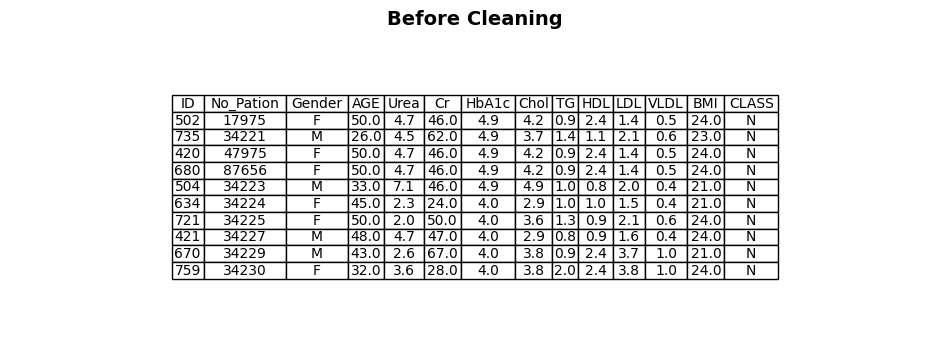

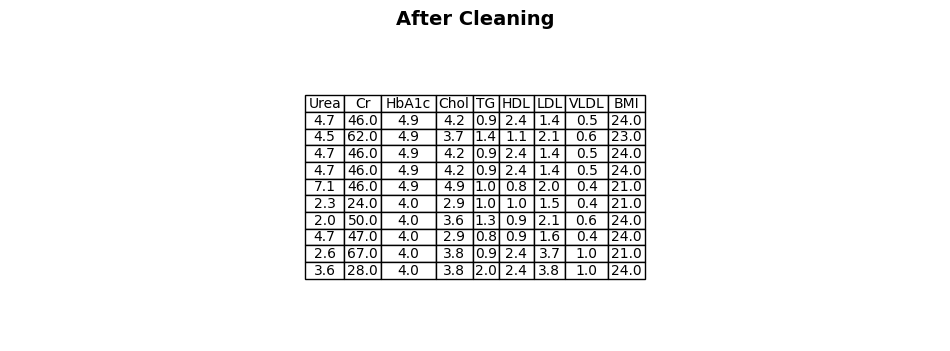

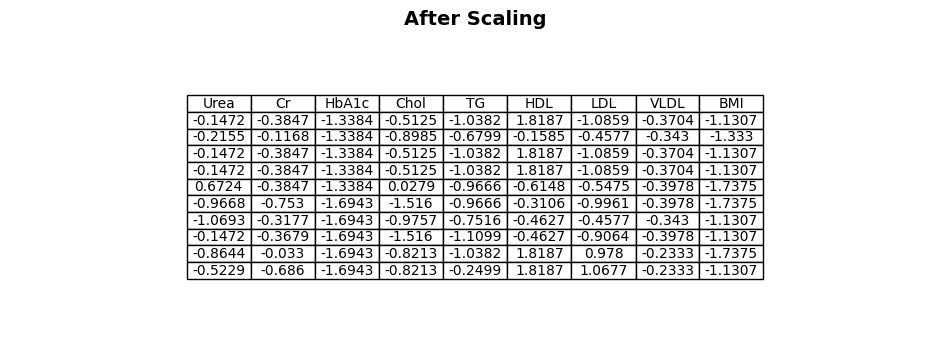

In [34]:

def plot_table(df, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=14)
    table = ax.table(cellText=df.head(10).values,
                     colLabels=df.columns,
                     cellLoc='center',
                     loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(df.columns))))

    plt.show()
plot_table(df, "Before Cleaning")
plot_table(df_Mean, "After Cleaning")
plot_table(df_scaled, "After Scaling")